# SmartPrice AI - A Laptop Value Prediction Engine

**Dataset:** `laptop_data_cleaned_final.csv`

**Steps covered:**
1. Import libraries & load data
2. Univariate Analysis(EDA)
3. Bivariate Analysis(EDA) 
4. Correlation Heatmap(EDA)
5. Data Preprocessing
6. Model Training — Linear Regression, KNN, Random Forest, SVM
7. Model Comparison
8. Export Best Model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style('whitegrid')
%matplotlib inline

print("Libraries imported successfully.")


Libraries imported successfully.


In [2]:
df = pd.read_csv('laptop_data_cleaned_final.csv')
print("Shape:", df.shape)
df.head()


Shape: (6000, 15)


,Company,TypeName,Ram,Weight,Touchscreen,Ips,ppi,Cpu_name,HDD,SSD,Hybrid,Flash_Storage,Gpu_brand,os,Price
0,Dell,Notebook,8,1.78,0,0,218.11,AMD Processor,0.0,512.0,0.0,0.0,Intel,Windows,107836.77
1,HP,Notebook,16,1.86,0,1,286.09,Intel Core i3,0.0,128.0,0.0,0.0,AMD,Others/No OS/Linux,116019.48
2,Acer,Gaming,16,3.88,0,0,111.94,Other Intel Processor,0.0,128.0,0.0,0.0,Nvidia,Windows,108031.24
3,Lenovo,2 in 1 Convertible,8,1.30,0,1,259.93,Intel Core i7,0.0,512.0,0.0,0.0,Intel,Windows,142466.75
4,Asus,Ultrabook,8,0.94,1,1,141.21,AMD Processor,0.0,256.0,0.0,0.0,AMD,Windows,94314.43


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Company        6000 non-null   object 
 1   TypeName       6000 non-null   object 
 2   Ram            6000 non-null   int64  
 3   Weight         6000 non-null   float64
 4   Touchscreen    6000 non-null   int64  
 5   Ips            6000 non-null   int64  
 6   ppi            6000 non-null   float64
 7   Cpu_name       6000 non-null   object 
 8   HDD            6000 non-null   float64
 9   SSD            6000 non-null   float64
 10  Hybrid         6000 non-null   float64
 11  Flash_Storage  6000 non-null   float64
 12  Gpu_brand      6000 non-null   object 
 13  os             6000 non-null   object 
 14  Price          6000 non-null   float64
dtypes: float64(7), int64(3), object(5)
memory usage: 703.3+ KB


In [4]:
df.isnull().sum()


Company          0
TypeName         0
Ram              0
Weight           0
Touchscreen      0
Ips              0
ppi              0
Cpu_name         0
HDD              0
SSD              0
Hybrid           0
Flash_Storage    0
Gpu_brand        0
os               0
Price            0
dtype: int64

In [5]:
df.describe()


,Ram,Weight,Touchscreen,Ips,ppi,HDD,SSD,Hybrid,Flash_Storage,Price
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,10.469667,2.132267,0.137000,0.297667,156.054387,375.556000,199.553333,11.333333,2.213333,96906.365120
std,8.993566,0.866219,0.343876,0.457270,48.100916,504.822699,225.366165,105.861970,10.139475,32633.608604
min,2.000000,0.900000,0.000000,0.000000,85.170000,0.000000,0.000000,0.000000,0.000000,25740.080000
25%,4.000000,1.440000,0.000000,0.000000,125.370000,0.000000,0.000000,0.000000,0.000000,74259.290000
50%,8.000000,1.985000,0.000000,0.000000,146.860000,0.000000,128.000000,0.000000,0.000000,92079.170000
75%,16.000000,2.580000,0.000000,1.000000,179.100000,1000.000000,256.000000,0.000000,0.000000,113444.377500
max,64.000000,4.700000,1.000000,1.000000,436.220000,2000.000000,1000.000000,1000.000000,64.000000,322284.220000


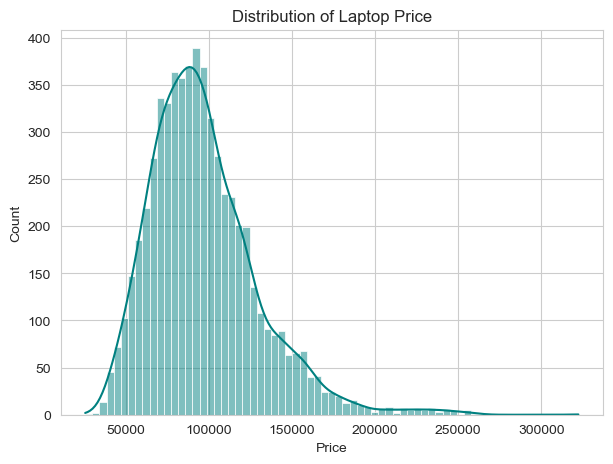

In [6]:
plt.figure(figsize=(7,5))
sns.histplot(df['Price'], kde=True, color='teal')
plt.title('Distribution of Laptop Price')
plt.xlabel('Price')
plt.show()


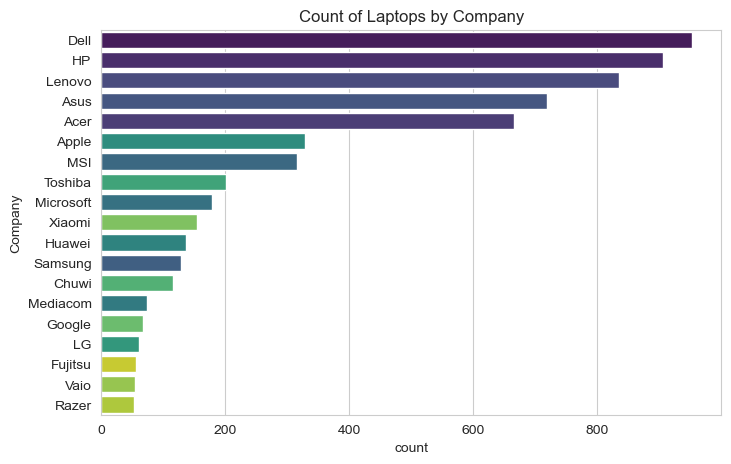

In [7]:
plt.figure(figsize=(8,5))
sns.countplot(y='Company', data=df, order=df['Company'].value_counts().index, hue='Company', legend=False, palette='viridis')
plt.title('Count of Laptops by Company')
plt.show()


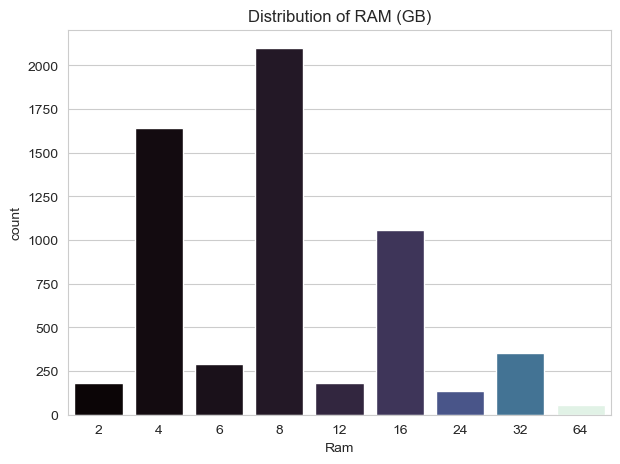

In [8]:
plt.figure(figsize=(7,5))
sns.countplot(x='Ram', data=df, order=sorted(df['Ram'].unique()), hue='Ram', legend=False, palette='mako')
plt.title('Distribution of RAM (GB)')
plt.show()


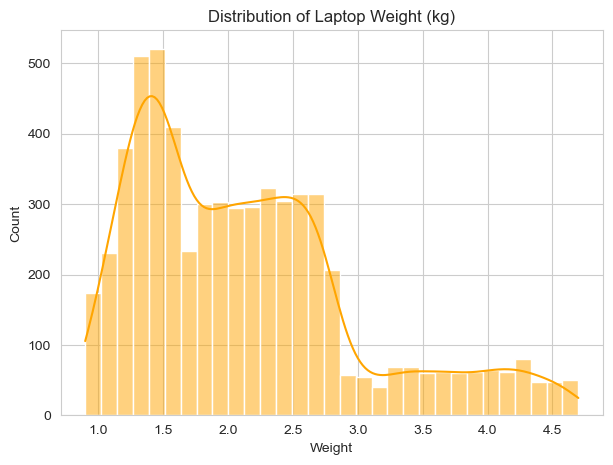

In [9]:
plt.figure(figsize=(7,5))
sns.histplot(df['Weight'], kde=True, color='orange')
plt.title('Distribution of Laptop Weight (kg)')
plt.show()


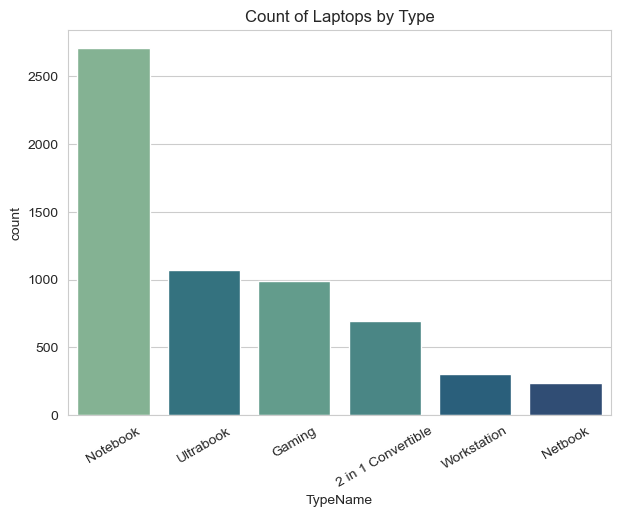

In [10]:
plt.figure(figsize=(7,5))
sns.countplot(x='TypeName', data=df, order=df['TypeName'].value_counts().index, hue='TypeName', legend=False, palette='crest')
plt.title('Count of Laptops by Type')
plt.xticks(rotation=30)
plt.show()


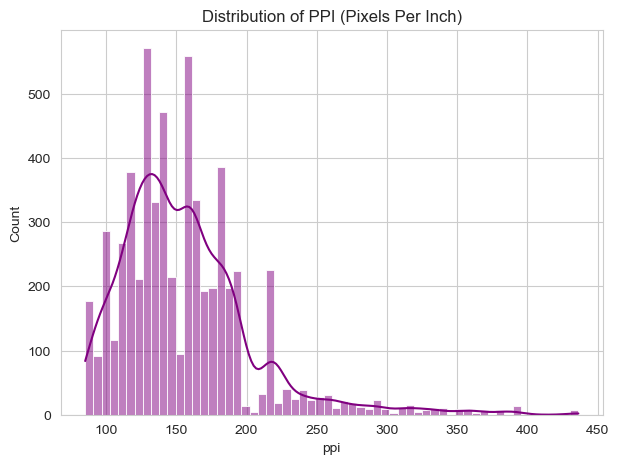

In [11]:
plt.figure(figsize=(7,5))
sns.histplot(df['ppi'], kde=True, color='purple')
plt.title('Distribution of PPI (Pixels Per Inch)')
plt.show()


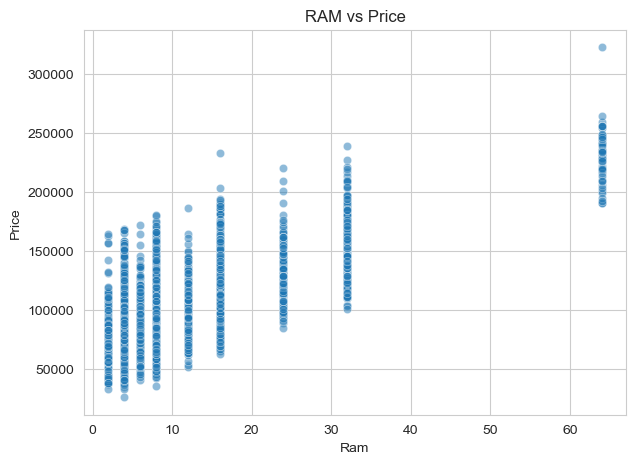

In [12]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='Ram', y='Price', data=df, alpha=0.5)
plt.title('RAM vs Price')
plt.show()


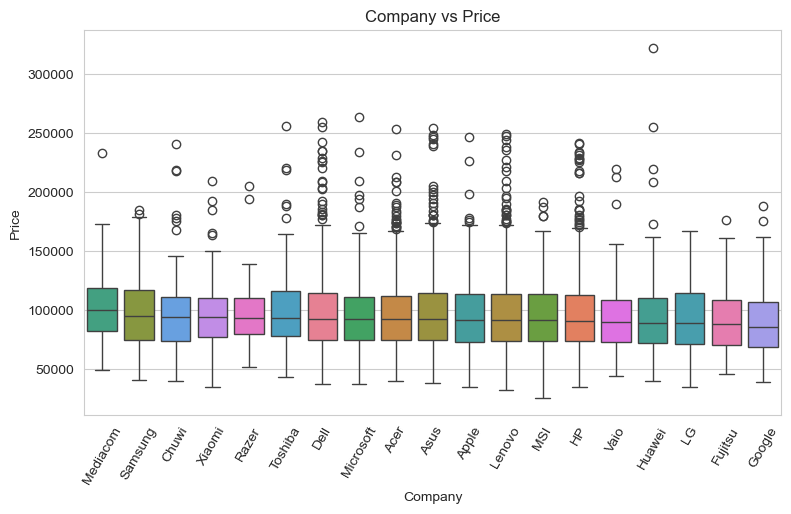

In [13]:
plt.figure(figsize=(9,5))
order = df.groupby('Company')['Price'].median().sort_values(ascending=False).index
sns.boxplot(x='Company', y='Price', data=df, order=order, hue='Company', legend=False)
plt.title('Company vs Price')
plt.xticks(rotation=60)
plt.show()


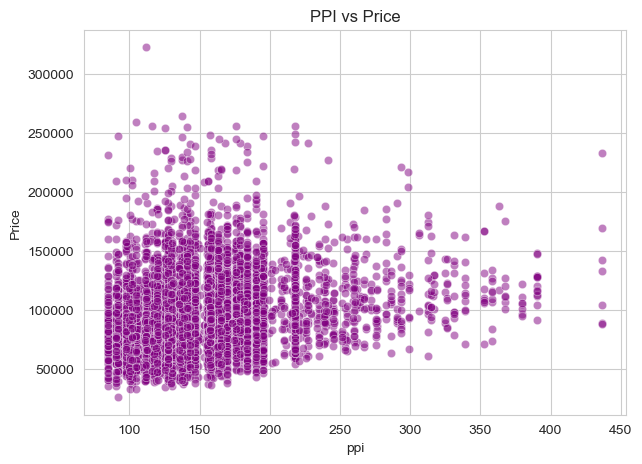

In [14]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='ppi', y='Price', data=df, alpha=0.5, color='purple')
plt.title('PPI vs Price')
plt.show()


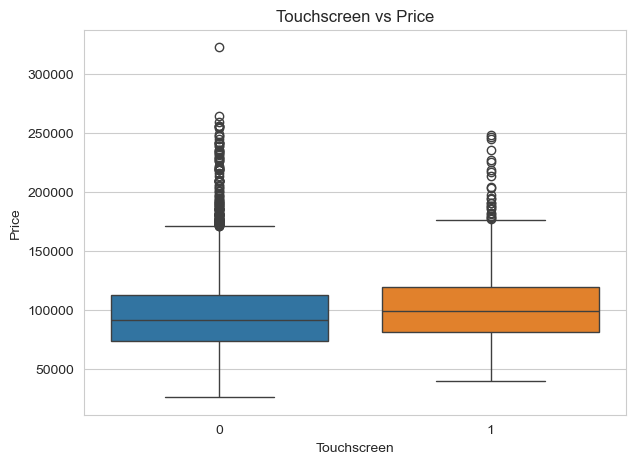

In [15]:
plt.figure(figsize=(7,5))
sns.boxplot(x='Touchscreen', y='Price', data=df, hue='Touchscreen', legend=False)
plt.title('Touchscreen vs Price')
plt.show()


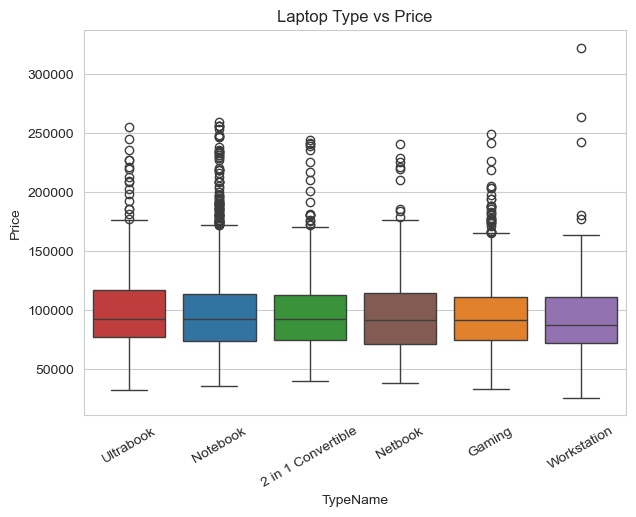

In [16]:
plt.figure(figsize=(7,5))
order2 = df.groupby('TypeName')['Price'].median().sort_values(ascending=False).index
sns.boxplot(x='TypeName', y='Price', data=df, order=order2, hue='TypeName', legend=False)
plt.title('Laptop Type vs Price')
plt.xticks(rotation=30)
plt.show()


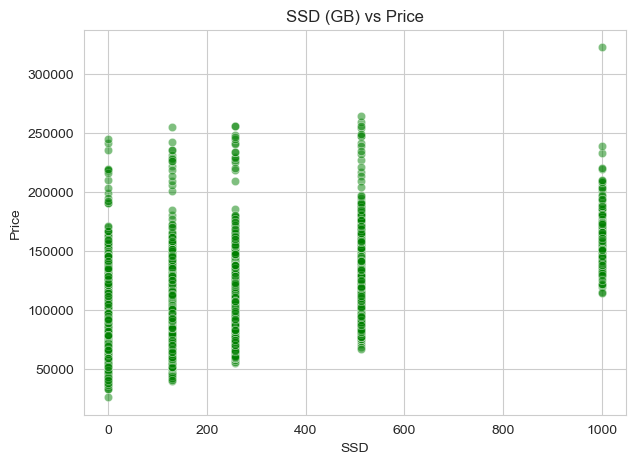

In [17]:
plt.figure(figsize=(7,5))
sns.scatterplot(x='SSD', y='Price', data=df, alpha=0.5, color='green')
plt.title('SSD (GB) vs Price')
plt.show()


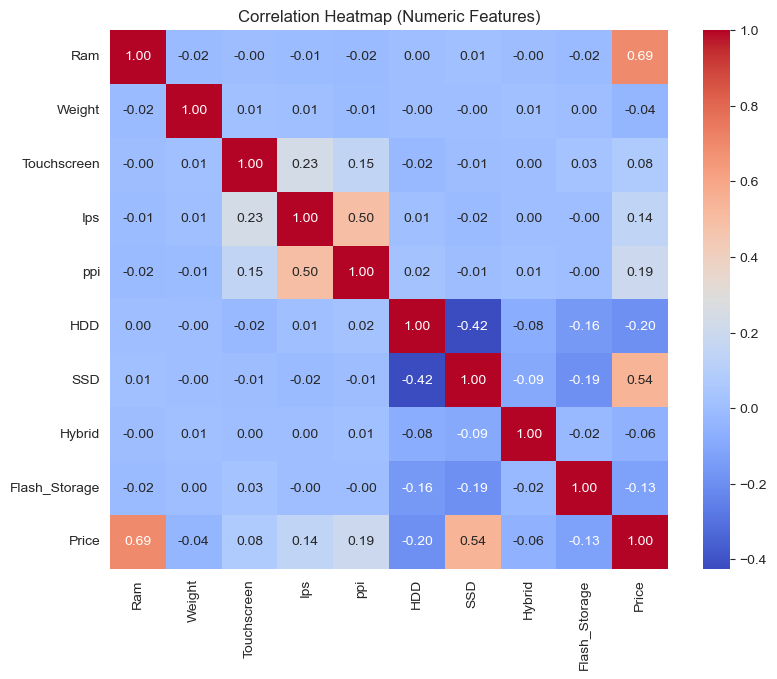

In [18]:
num_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(9,7))
sns.heatmap(num_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()


In [19]:
# data preprocess
X = df.drop(columns=['Price'])
y = np.log(df['Price'])  # log-transform target to reduce right-skew

cat_cols = ['Company', 'TypeName', 'Cpu_name', 'Gpu_brand', 'os']
num_cols = [c for c in X.columns if c not in cat_cols]

preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (5100, 14)  Test shape: (900, 14)


In [20]:
# model train
models = {
    'Linear Regression': LinearRegression(),
    'KNN': KNeighborsRegressor(n_neighbors=5),
    'Random Forest': RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1),
    'SVM (SVR)': SVR(kernel='rbf', C=10, epsilon=0.05)
}

results = {}
pipelines = {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds_log = pipe.predict(X_test)
    preds = np.exp(preds_log)
    actual = np.exp(y_test)
    r2 = r2_score(actual, preds)
    mae = mean_absolute_error(actual, preds)
    rmse = np.sqrt(mean_squared_error(actual, preds))
    results[name] = {'R2': round(r2, 4), 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)}
    pipelines[name] = pipe
    print(f"{name:20s} -> R2: {r2:.4f} | MAE: {mae:.2f} | RMSE: {rmse:.2f}")


Linear Regression    -> R2: 0.7489 | MAE: 7211.00 | RMSE: 16861.34
KNN                  -> R2: 0.8353 | MAE: 10277.51 | RMSE: 13656.26
Random Forest        -> R2: 0.9508 | MAE: 5619.59 | RMSE: 7464.14
SVM (SVR)            -> R2: 0.9255 | MAE: 5765.97 | RMSE: 9184.81


In [21]:
#model compare
results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)
results_df 


,R2,MAE,RMSE
Random Forest,0.9508,5619.59,7464.14
SVM (SVR),0.9255,5765.97,9184.81
KNN,0.8353,10277.51,13656.26
Linear Regression,0.7489,7211.00,16861.34


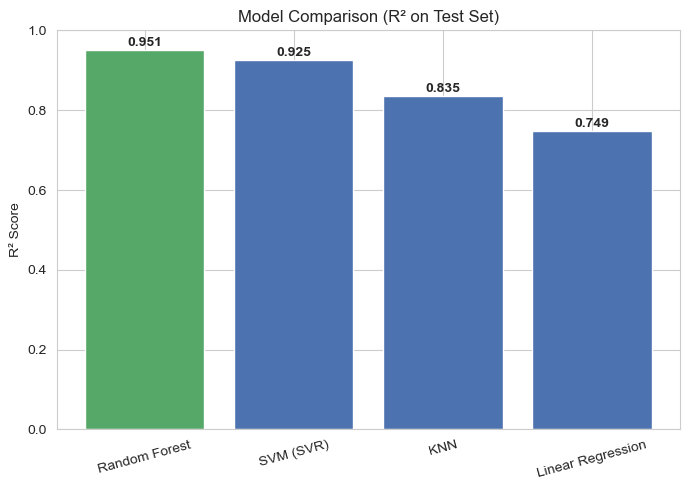

In [22]:
plt.figure(figsize=(7,5))
colors = ['#55A868' if i == 0 else '#4C72B0' for i in range(len(results_df))]
bars = plt.bar(results_df.index, results_df['R2'], color=colors)
plt.ylabel('R² Score')
plt.title('Model Comparison (R² on Test Set)')
plt.ylim(0, 1)
for b, v in zip(bars, results_df['R2']):
    plt.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [25]:
# best accuracy model
best_name = results_df.index[0]
best_pipe = pipelines[best_name]
print(f"Best Model: {best_name}  (R2 = {results_df.loc[best_name, 'R2']})")

joblib.dump(best_pipe, 'laptop_price_model.pkl')
print("Model exported as 'laptop_price_model.pkl'")


Best Model: Random Forest  (R2 = 0.9508)
Model exported as 'laptop_price_model.pkl'


In [24]:
loaded_model = joblib.load('laptop_price_model.pkl')
sample = X_test.iloc[[0]]
predicted_price = np.exp(loaded_model.predict(sample))[0]
actual_price = np.exp(y_test.iloc[0])
print(f"Predicted Price: Rs.{predicted_price:,.2f}")
print(f"Actual Price:    Rs.{actual_price:,.2f}")


Predicted Price: Rs.115,233.99
Actual Price:    Rs.107,961.60
